# Advanced Models - Random Forest & XGBoost
Advanced training models and comparing them against the baseline.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('../data/train_processed.csv')

FEATURES = ['Pclass', 'Sex_encoded', 'Age', 'FamilySize', 'IsAlone',
            'LogFare', 'Embarked_encoded', 'Title_encoded', 'AgeBand_encoded']

X = train[FEATURES]
y = train['Survived']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [11]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
print(f'Random Forest CV: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})')

Random Forest CV: 0.8350 (+/- 0.0099)


In [12]:
# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0
)

xgb_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='accuracy')
print(f'XGBoost CV: {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})')

XGBoost CV: 0.8417 (+/- 0.0067)


In [13]:
# --- Logistic Regression baseline (for comparison) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lr = LogisticRegression(random_state=42, max_iter=500)
lr_scores = cross_val_score(lr, X_scaled, y, cv=cv, scoring='accuracy')
print(f'Logistic Regression CV: {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})')

Logistic Regression CV: 0.8002 (+/- 0.0139)


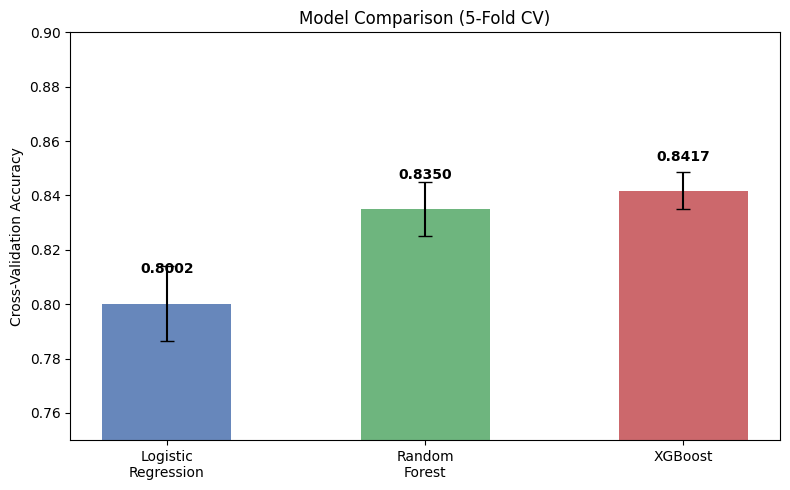

In [14]:
# Model Comparison Chart
models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
means = [lr_scores.mean(), rf_scores.mean(), xgb_scores.mean()]
stds = [lr_scores.std(), rf_scores.std(), xgb_scores.std()]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, means, yerr=stds, capsize=5,
               color=['#4C72B0', '#55A868', '#C44E52'], alpha=0.85, width=0.5)

for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.010,
             f'{mean:.4f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0.75, 0.90)
plt.ylabel('Cross-Validation Accuracy')
plt.title('Model Comparison (5-Fold CV)')
plt.tight_layout()
plt.savefig('../plots/model_comparison.png', dpi=150)
plt.show()

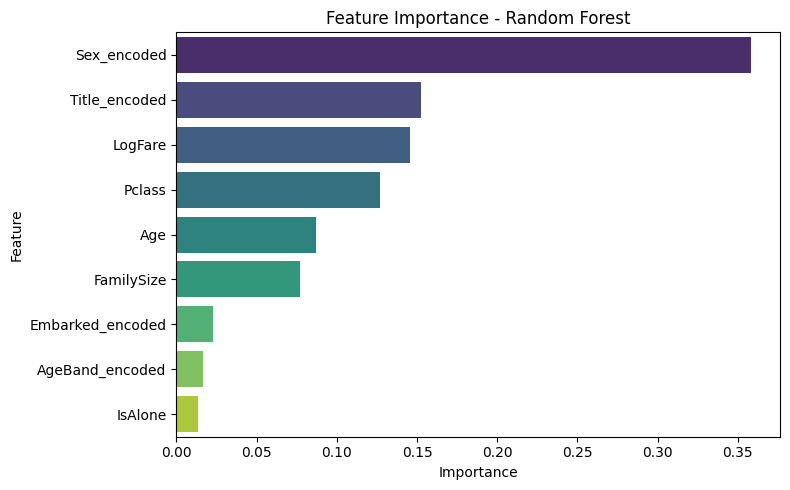

            Feature  Importance
1       Sex_encoded    0.358349
7     Title_encoded    0.152241
5           LogFare    0.145841
0            Pclass    0.126877
2               Age    0.087113
3        FamilySize    0.076793
6  Embarked_encoded    0.022679
8   AgeBand_encoded    0.016708
4           IsAlone    0.013399


In [15]:
# Feature Importance - Random Forest

rf.fit(X, y)

feat_importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('../plots/feature_importance_rf.png', dpi=150)
plt.show()

print(feat_importance)